In [1]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF


N = 10000
K = 5
W = 0.6
iterations = 10
MIN_S = 0.3
MAX_S = 0.95
modes = [1,2,3,4,5]

cols = ['condition', 't', 't_est', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score', 'true_score', 'algorithm', 'mode']

scores = pd.DataFrame(columns=cols)

for mode in modes:
    for exp in tqdm(range(iterations)):
        data = Data()
        data.generate(n=N, seed=exp, mode=mode)
        data.generate_random_condition(min_s=MIN_S, max_s=MAX_S)

        ct_D = CT(data, on = "D")
        ct_D.fit(max_depth=6)
        ct_D.parse_tree()

        ct_P = CT(data, on = "P")
        ct_P.fit(max_depth=6)
        ct_P.parse_tree()

        cf_mse = CF(data)
        cf_mse.fit(criterion="mse", n_estimators=100, max_depth=4)
        cf_mse.parse_forest()  

    
        for alg in [ct_D, ct_P, cf_mse]:
            score = alg.get_topK(k=K, w=W, print_summaries=False)
            score['mode'] = mode
            scores=pd.concat([scores, score], ignore_index=True)

        cf_mse.single_tree_interpreter(max_depth=10)

        score2 = cf_mse.get_topK(k=K, w=W, print_summaries=False)
        score2['mode'] = mode
        scores=pd.concat([scores, score2], ignore_index=True)

100%|██████████| 10/10 [03:40<00:00, 22.06s/it]


# Modes

The different modes are:
- 1 for difficult nuisance components and an easy treatment effect. 
- 2 for a randomized trial. 
- 3 for an easy propensity and a difficult baseline. 
- 4 for unrelated treatment and control groups. 
- 5 for a hidden confounder biasing treatment.

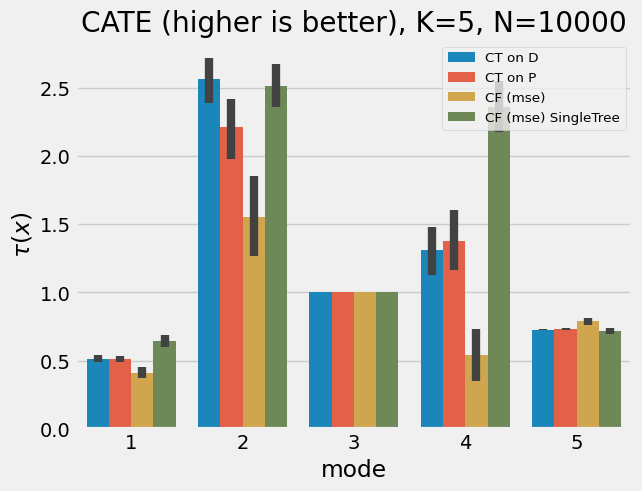

In [2]:
sns.barplot(x='mode', y='t', hue='algorithm', data=scores)
plt.title(f"CATE (higher is better), K={str(K)}, N={str(N)}")
plt.ylabel(r"$\tau(x)$")
plt.legend(fontsize='x-small')
plt.show()

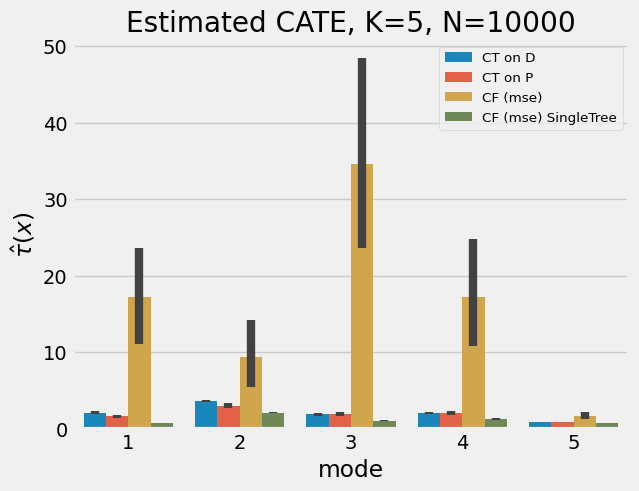

In [3]:
sns.barplot(x='mode', y='t_est', hue='algorithm', data=scores)
plt.title(fr"Estimated CATE, K={str(K)}, N={str(N)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.legend(fontsize='x-small')
plt.show()

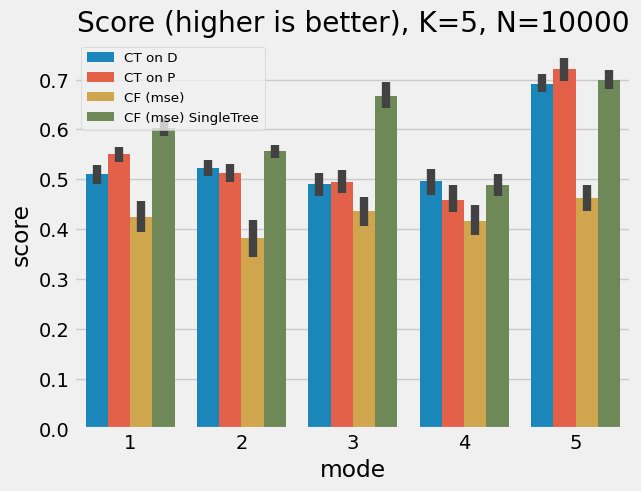

In [4]:
sns.barplot(x='mode', y='score', hue='algorithm', data=scores)
plt.title(f"Score (higher is better), K={str(K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

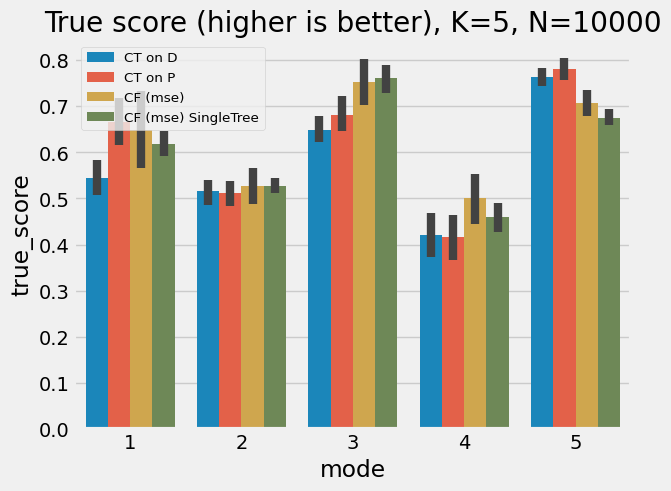

In [5]:
sns.barplot(x='mode', y='true_score', hue='algorithm', data=scores)
plt.title(f"True score (higher is better), K={str(K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

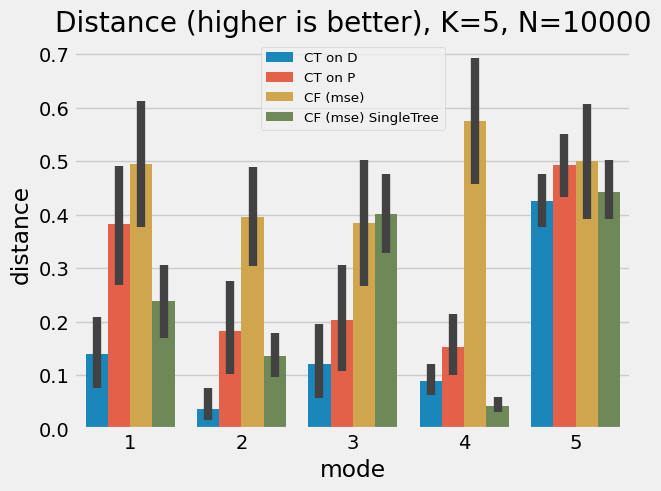

In [6]:
sns.barplot(x='mode', y='distance', hue='algorithm', data=scores)
plt.title(f"Distance (higher is better), K={str(K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

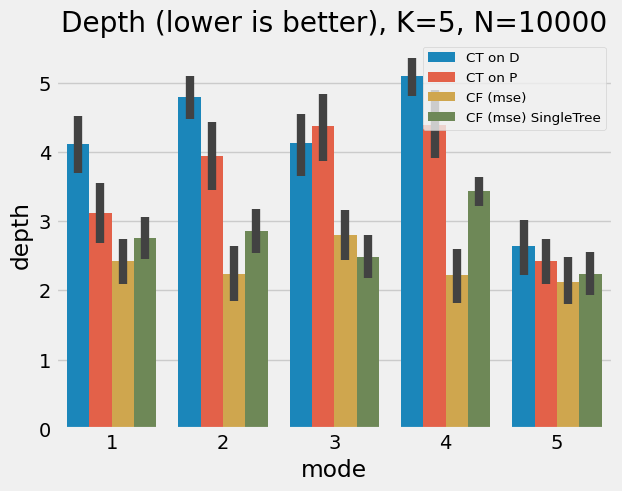

In [7]:
sns.barplot(x='mode', y='depth', hue="algorithm", data=scores)
plt.title(f"Depth (lower is better), K={str(K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

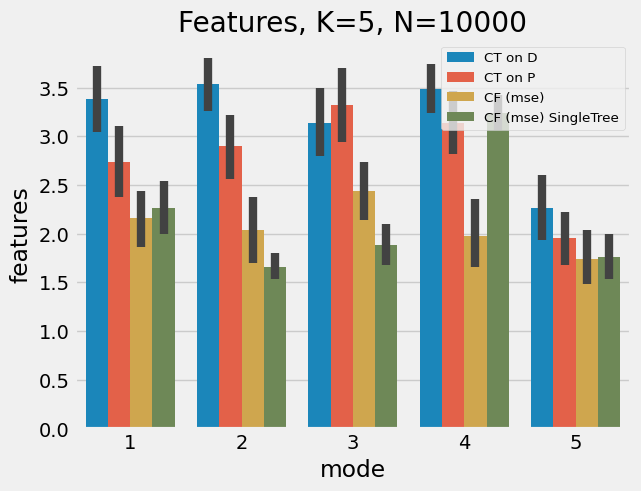

In [8]:
sns.barplot(x='mode', y='features', hue="algorithm", data=scores)
plt.title(f"Features, K={str(K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

In [9]:
import pickle as pkl

with open("modes.pkl", "wb") as f:
    pkl.dump(modes, f)